In [ ]:
# sudo apt install python3-venv
# python3 -m venv myenv
# source myenv/bin/activate
# pip install notebook
# jupyter notebook
# pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn


In [11]:
# Step 1: Import Libraries
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt



In [14]:
import pandas as pd

data = pd.read_csv("boston.csv")


In [15]:
print(data.columns)

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


In [16]:
X = data.drop("medv", axis=1)
y = data["medv"]

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Step 3: Standardization
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [19]:
# Step 4: Build Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(13,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Step 5: Compile Model
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])

In [21]:
# Step 6: Train Model
model.fit(x_train, y_train,
          epochs=50,
          batch_size=16)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 611.3577 - mean_absolute_error: 22.8966
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 540.8639 - mean_absolute_error: 21.2852
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 427.0631 - mean_absolute_error: 18.4594
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 282.9205 - mean_absolute_error: 14.3766
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 131.8975 - mean_absolute_error: 9.0288
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.8741 - mean_absolute_error: 6.0602
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40.3780 - mean_absolute_error: 4.7606
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.6613 - mean_absolute_error: 4.1900
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.7306 - mean_absolute_error: 3.6472
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.4437 - mean_absolute_error: 3.5993
Epoch 11/50
26/26 ━━━━━━━━━━━━

In [22]:
# Step 7: Prediction
y_pred = model.predict(x_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [23]:
# Step 8: Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.189810821121814
MSE: 11.073646290150903
R2 Score: 0.848996658662194


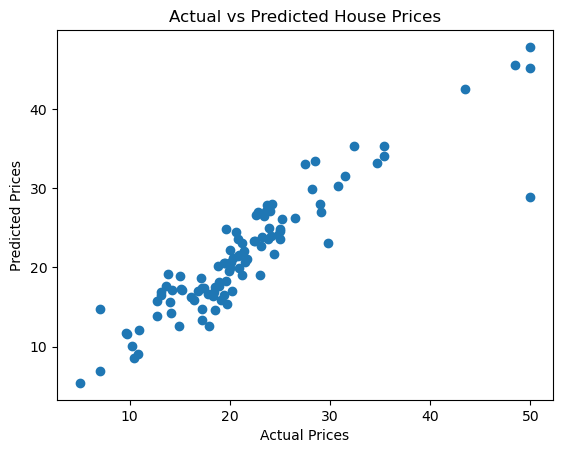

In [24]:
# Step 9: Graph (Actual vs Predicted)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [25]:
# Good. I’ll explain the **entire code step-by-step in simple SPPU style**, including **why each library and step is used**.

# ---

# # Full Code Explanation (SPPU Style)

# ---

# ## Step 1: Import Libraries

# ```python
# import tensorflow as tf
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import matplotlib.pyplot as plt
# ```

# ### Why these libraries?

# ### 1. TensorFlow

# * Used to build and train the **Deep Neural Network**
# * Provides layers, models, and training functions

# ---

# ### 2. StandardScaler (from sklearn)

# * Used for **standardization of data**
# * Converts data to:

#   * Mean = 0
#   * Standard deviation = 1

# Why needed?

# * Neural networks perform better when data is normalized

# ---

# ### 3. Metrics (MAE, MSE, R2)

# * Used to **evaluate model performance**

# * MAE → average error

# * MSE → squared error

# * R2 → accuracy of model

# ---

# ### 4. Matplotlib

# * Used to **plot graph**
# * Helps visualize results

# ---

# ## Step 2: Load Dataset

# ```python
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.boston_housing.load_data()
# ```

# ### Explanation:

# * Loads Boston Housing dataset
# * Automatically splits into:

#   * Training data
#   * Testing data

# ---

# ### What are variables?

# * `x_train` → input features (training)
# * `y_train` → output values (training)
# * `x_test` → input features (testing)
# * `y_test` → actual prices

# ---

# ## Step 3: Standardization

# ```python
# scaler = StandardScaler()

# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)
# ```

# ### Explanation:

# * `fit_transform()` → learns and transforms training data
# * `transform()` → applies same transformation on test data

# ---

# ### Why important?

# Without scaling:

# * Some features may dominate others
# * Model learns poorly

# ---

# ## Step 4: Build Model

# ```python
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Dense(64, activation='relu', input_shape=(13,)),
#     tf.keras.layers.Dense(32, activation='relu'),
#     tf.keras.layers.Dense(1)
# ])
# ```

# ### Explanation:

# ### Sequential Model

# * Layers are added one after another

# ---

# ### Layer 1:

# ```python
# Dense(64, activation='relu', input_shape=(13,))
# ```

# * 64 neurons
# * ReLU activation
# * Input size = 13 features

# ---

# ### Layer 2:

# ```python
# Dense(32, activation='relu')
# ```

# * 32 neurons
# * Learns deeper patterns

# ---

# ### Output Layer:

# ```python
# Dense(1)
# ```

# * 1 output → house price

# ---

# ## Step 5: Compile Model

# ```python
# model.compile(optimizer='adam',
#               loss='mean_squared_error',
#               metrics=['mean_absolute_error'])
# ```

# ### Explanation:

# ### Optimizer = Adam

# * Updates weights during training
# * Fast and efficient

# ---

# ### Loss = MSE

# * Measures error
# * Used for regression problems

# ---

# ### Metric = MAE

# * Used to monitor performance

# ---

# ## Step 6: Train Model

# ```python
# model.fit(x_train, y_train,
#           epochs=50,
#           batch_size=16)
# ```

# ### Explanation:

# * `epochs=50` → model trains 50 times
# * `batch_size=16` → 16 samples per step

# ---

# ### What happens here?

# * Model learns patterns
# * Adjusts weights using backpropagation

# ---

# ## Step 7: Prediction

# ```python
# y_pred = model.predict(x_test)
# ```

# ### Explanation:

# * Model predicts house prices
# * Uses unseen test data

# ---

# ## Step 8: Evaluation

# ```python
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("MSE:", mean_squared_error(y_test, y_pred))
# print("R2 Score:", r2_score(y_test, y_pred))
# ```

# ### Explanation:

# * Compares predicted vs actual values

# ---

# ### Metrics meaning:

# * MAE → average error
# * MSE → squared error
# * R2 → how well model fits

# ---

# ## Step 9: Graph

# ```python
# plt.scatter(y_test, y_pred)
# plt.xlabel("Actual Prices")
# plt.ylabel("Predicted Prices")
# plt.title("Actual vs Predicted House Prices")
# plt.show()
# ```

# ### Explanation:

# * X-axis → actual values
# * Y-axis → predicted values

# ---

# ### Interpretation:

# * Points near straight line → good model
# * Scattered points → poor model

# ---

# # Final Flow Summary (Important for Viva)

# 1. Import libraries
# 2. Load dataset
# 3. Standardize data
# 4. Build DNN model
# 5. Compile model
# 6. Train model
# 7. Predict values
# 8. Evaluate performance
# 9. Plot graph

# ---

# # One-Line Explanation (Say This in Viva)

# “This program uses a deep neural network to perform regression on the Boston Housing dataset. The data is standardized, the model is trained using Adam optimizer and MSE loss, and performance is evaluated using MAE, MSE, and R2 score.”

# ---

# If you want next:
# I can give you **perfect journal write-up + viva answers in short format**.

# “The model shows good performance. The MAE and MSE values are low, and the R² score of 0.85 indicates that the model explains most of the variance in the dataset.”